# Final Project.- Training a Machine Learning model on medical images.

**Authors:**
- Eugenio Espronceda Acosta
- René Alejandro Rodríguez Castañeda
- Manuel Alejandro Juárez Grimaldo

**Student IDs:**
- 2096538
- 2019068
- 2115290

**Class Schedule: V4**

**Group** 001


# Proyecto final - Inteligencia Artificial

# Introduccion

Para este proyecto vamos a entrenar una CNN para clasificar imagenes de lesiones de piel usando
el dataset HAM10000 (son dermatoscopias, osea fotos tomadas con un dermatoscopio).

Dataset: https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
Paper original: https://www.nature.com/articles/sdata2018161

El dataset tiene 10,015 imagenes y cada una tiene una de 7 posibles clases (tipo de lesion):

- akiec
- bcc
- bkl
- df
- mel
- nv
- vasc

nv es por mucho la clase con mas imagenes (como el 67% del dataset), asi que hay que tener
cuidado con eso a la hora de entrenar.


# Librerias

In [43]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

np.random.seed(42)
tf.random.set_seed(42)


# Preprocesamiento

Aqui cargamos las imagenes, las metemos a un mismo tamano y separamos en train/test.

Usamos 80% para entrenamiento y 20% para test. Como nv tiene muchisimas mas imagenes que las
demas clases usamos stratify en el train_test_split para que la proporcion de clases se mantenga
igual en ambos conjuntos (si no, se puede dar el caso de que el test set se quede sin ejemplos de
alguna clase rara como df).


In [44]:
# En Kaggle el dataset ya viene montado en /kaggle/input, aqui nada mas buscamos donde esta
DATA_DIR = "/kaggle/input/skin-cancer-mnist-ham10000"

if not os.path.isdir(DATA_DIR):
    # si no estas en kaggle, lo bajamos con kagglehub
    import kagglehub
    DATA_DIR = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

print(DATA_DIR)
os.listdir(DATA_DIR)


C:\Users\letyc\.cache\kagglehub\datasets\kmader\skin-cancer-mnist-ham10000\versions\2


['HAM10000_images_part_1',
 'HAM10000_images_part_2',
 'HAM10000_metadata.csv',
 'hmnist_28_28_L.csv',
 'hmnist_28_28_RGB.csv',
 'hmnist_8_8_L.csv',
 'hmnist_8_8_RGB.csv']

In [45]:
df = pd.read_csv(os.path.join(DATA_DIR, "HAM10000_metadata.csv"))
df.head()


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [46]:
# las imagenes estan repartidas en dos carpetas, hay que armar la ruta completa de cada una
rutas = {}
for carpeta in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    p = os.path.join(DATA_DIR, carpeta)
    if os.path.isdir(p):
        for nombre in os.listdir(p):
            rutas[nombre.replace(".jpg", "")] = os.path.join(p, nombre)

df["path"] = df["image_id"].map(rutas)
df = df.dropna(subset=["path"]).reset_index(drop=True)
len(df)


10015

In [47]:
df["dx"].value_counts()


dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

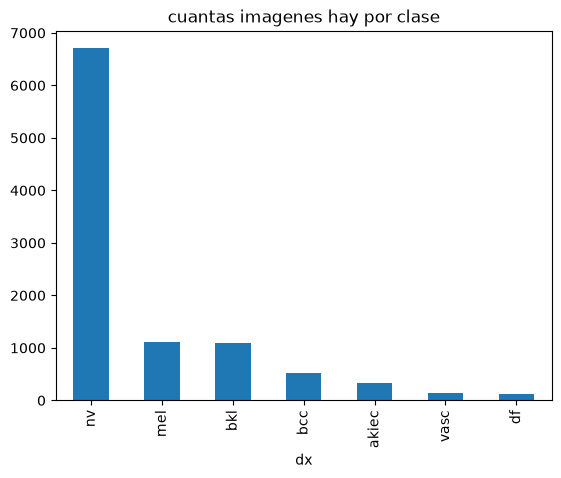

In [48]:
df["dx"].value_counts().plot(kind="bar")
plt.title("cuantas imagenes hay por clase")
plt.show()


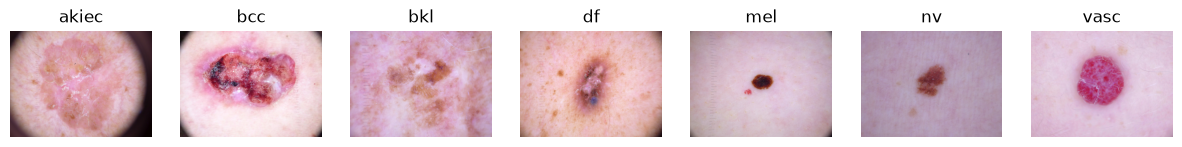

In [49]:
# preview rapido, una imagen de cada clase para ver que se ven bien
clases = sorted(df["dx"].unique())
fig, axs = plt.subplots(1, len(clases), figsize=(15, 3))
for ax, c in zip(axs, clases):
    ruta = df[df.dx == c].path.iloc[0]
    img = cv2.cvtColor(cv2.imread(ruta), cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(c)
    ax.axis("off")
plt.show()


In [50]:
# resize + cargar todo a un array. Usamos 64x64 porque con el tamano original
# (600x450) se tarda muchisimo en entrenar y no tenemos tanto poder de computo
IMG_SIZE = 64

def cargar_imagen(ruta):
    img = cv2.imread(ruta)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

# esto tarda un rato, son como 10 mil imagenes
imagenes = np.array([cargar_imagen(p) for p in df["path"]])
imagenes.shape


(10015, 64, 64, 3)

In [51]:
# convertir las etiquetas de texto (akiec, bcc, etc) a numeros
le = LabelEncoder()
etiquetas = le.fit_transform(df["dx"])
clases_nombres = le.classes_
list(clases_nombres)


['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

In [52]:
train_images, test_images, train_labels, test_labels = train_test_split(
    imagenes, etiquetas,
    test_size=0.2,
    random_state=42,
    stratify=etiquetas
)

train_images.shape, test_images.shape


((8012, 64, 64, 3), (2003, 64, 64, 3))

In [53]:
train_images.shape


(8012, 64, 64, 3)

In [54]:
len(train_labels)


8012

In [55]:
train_labels[:10]


array([5, 5, 0, 5, 5, 5, 2, 2, 5, 0])

In [56]:
test_images.shape


(2003, 64, 64, 3)

In [57]:
len(test_labels)


2003

In [58]:
# normalizar a valores entre 0 y 1
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0


In [59]:
# como el dataset esta desbalanceado (nv tiene muchas mas imagenes que el resto)
# calculamos pesos por clase para que el modelo no aprenda a solo predecir "nv" siempre
pesos = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)
pesos = np.sqrt(pesos)
pesos_dict = dict(enumerate(pesos))
pesos_dict


{0: np.float64(2.0901179963873444),
 1: np.float64(1.6687855838876697),
 2: np.float64(1.1411086901532987),
 3: np.float64(3.5271792963811572),
 4: np.float64(1.134034969920066),
 5: np.float64(0.46193095443886123),
 6: np.float64(3.1686117229200814)}

# Estructura y entrenamiento de la CNN

Usamos 3 capas convolucionales con maxpooling, y al final un par de capas densas. La ultima capa
tiene 7 neuronas (una por clase) con softmax porque es clasificacion multiclase.


In [60]:
# parte convolucional
model = models.Sequential()
model.add(layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)))

model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(layers.MaxPooling2D((2, 2)))


In [61]:
# parte de aprendizaje (fully connected)
model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))  # para no sobreajustar tanto
model.add(layers.Dense(7, activation='softmax'))

model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,142,855 (4.36 MB)

 Trainable params: 1,142,855 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])


In [63]:
# entrenamiento, 15 epocas porque con mas ya no mejoraba mucho y con menos no terminaba
# de aprender bien
history = model.fit(
    train_images, train_labels,
    epochs=15,
    batch_size=32,
    validation_data=(test_images, test_labels),
    class_weight=pesos_dict
)


Epoch 1/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 26s 89ms/step - accuracy: 0.6430 - loss: 1.2610 - val_accuracy: 0.6655 - val_loss: 1.1761
Epoch 2/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 25s 100ms/step - accuracy: 0.6288 - loss: 1.1412 - val_accuracy: 0.6700 - val_loss: 0.9760
Epoch 3/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 38s 88ms/step - accuracy: 0.6304 - loss: 1.0753 - val_accuracy: 0.6770 - val_loss: 0.8747
Epoch 4/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.6377 - loss: 1.0187 - val_accuracy: 0.6745 - val_loss: 0.8546
Epoch 5/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 90ms/step - accuracy: 0.6497 - loss: 0.9592 - val_accuracy: 0.6835 - val_loss: 0.8182
Epoch 6/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 91ms/step - accuracy: 0.6623 - loss: 0.9303 - val_accuracy: 0.6970 - val_loss: 0.7978
Epoch 7/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 39s 85ms/step - accuracy: 0.6585 - loss: 0.9000 - val_accuracy: 0.6865 - val_loss: 0.7927
Epoch 8/15
251/251 ━━━━━━━━━━━━━━━━━━━━ 24s 96ms/step - accuracy: 0.6575 - loss: 0.8747 -

# Resultados de precision de la CNN

Comparamos el accuracy de entrenamiento contra el de validacion en cada epoca. Si el de
entrenamiento sigue subiendo pero el de validacion se queda plano (o baja), es señal de
overfitting.


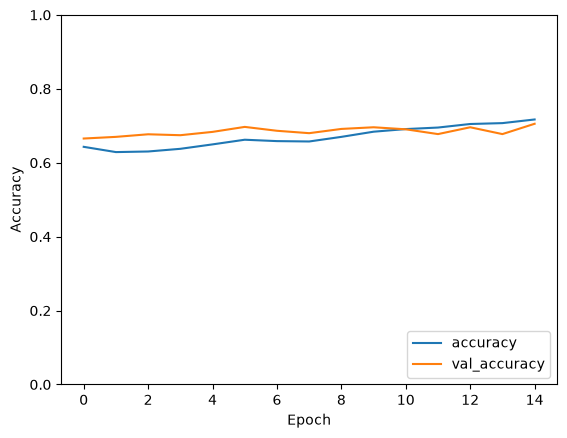

63/63 - 2s - 32ms/step - accuracy: 0.7054 - loss: 0.7804
accuracy en test: 0.7054418325424194


In [68]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print("accuracy en test:", test_acc)


# Predicciones con la CNN ya entrenada

Mostramos 10 predicciones del modelo sobre imagenes del set de test, comparando lo que predijo
contra la clase real.


In [65]:
predictions = model.predict(test_images)
pred_labels = np.argmax(predictions, axis=1)


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step


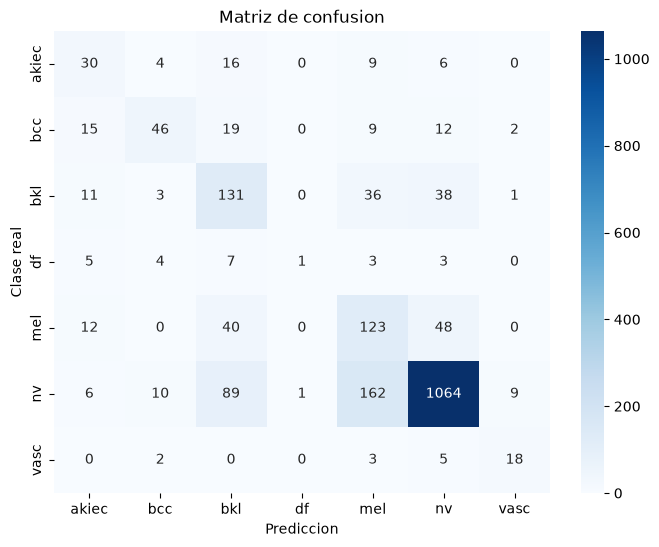

              precision    recall  f1-score   support

       akiec       0.38      0.46      0.42        65
         bcc       0.67      0.45      0.53       103
         bkl       0.43      0.60      0.50       220
          df       0.50      0.04      0.08        23
         mel       0.36      0.55      0.43       223
          nv       0.90      0.79      0.85      1341
        vasc       0.60      0.64      0.62        28

    accuracy                           0.71      2003
   macro avg       0.55      0.50      0.49      2003
weighted avg       0.75      0.71      0.72      2003



In [66]:
# Matriz de confusion y reporte de clasificacion
cm = confusion_matrix(test_labels, pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=clases_nombres, yticklabels=clases_nombres)
plt.xlabel("Prediccion")
plt.ylabel("Clase real")
plt.title("Matriz de confusion")
plt.show()

print(classification_report(test_labels, pred_labels, target_names=clases_nombres))

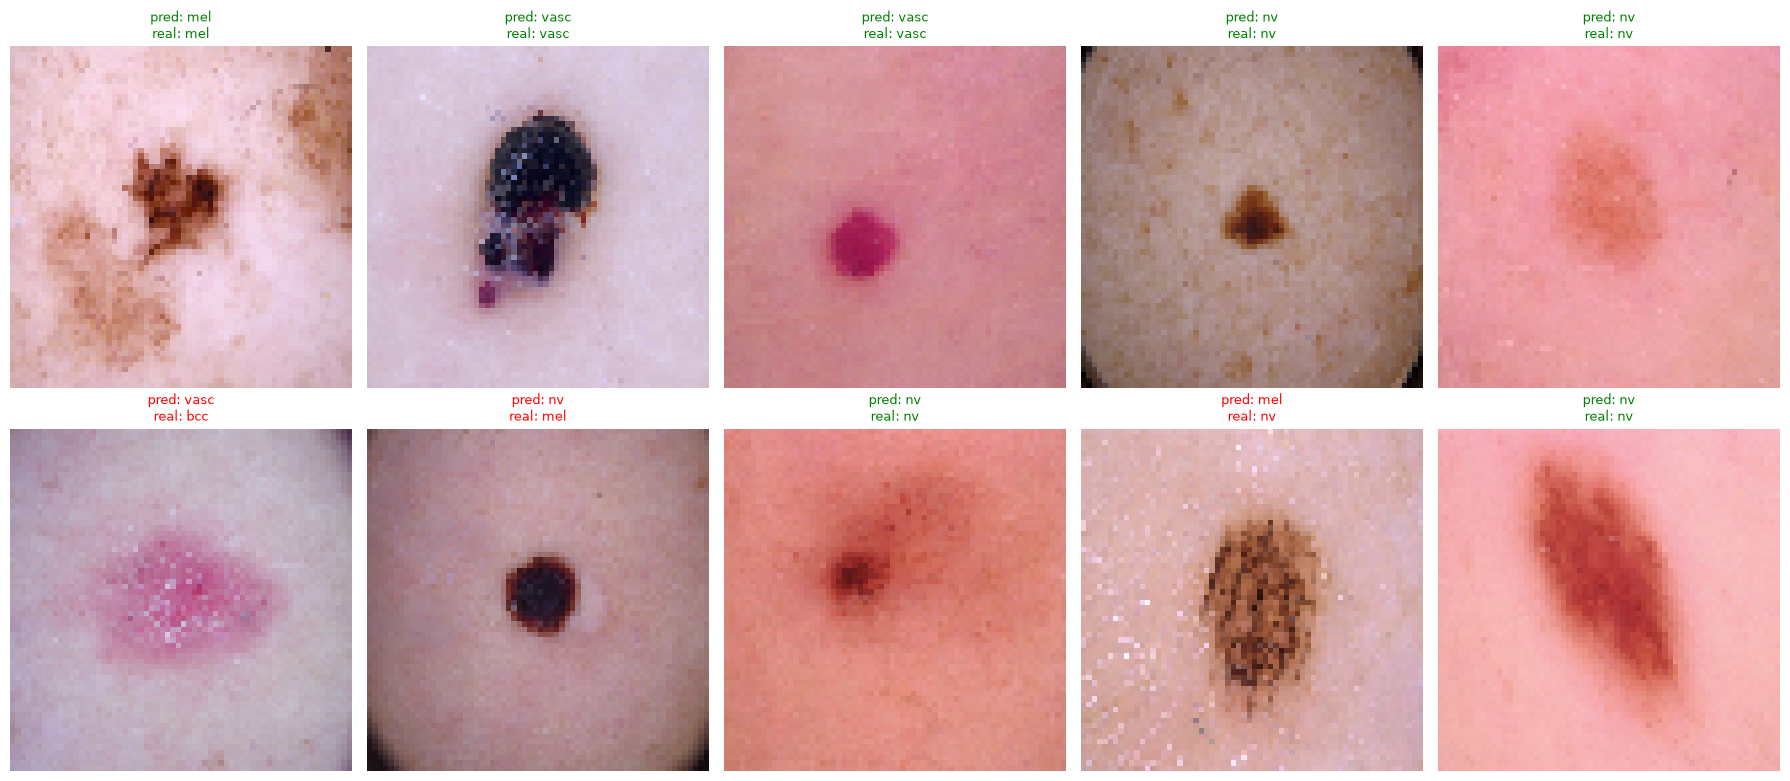

In [67]:
idx = np.random.choice(len(test_images), 10, replace=False)

plt.figure(figsize=(18, 8))
for i, k in enumerate(idx):
    pred = pred_labels[k]
    real = test_labels[k]
    plt.subplot(2, 5, i + 1)
    plt.imshow(test_images[k])
    color = "green" if pred == real else "red"
    plt.title(f"pred: {clases_nombres[pred]}\nreal: {clases_nombres[real]}", color=color, fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [39]:
for k in idx:
    x = clases_nombres[pred_labels[k]]
    y = clases_nombres[test_labels[k]]
    print("La red dice que la imagen es clase " + x + " y la clase verdadera es: " + y)


La red dice que la imagen es clase nv y la clase verdadera es: nv
La red dice que la imagen es clase mel y la clase verdadera es: nv
La red dice que la imagen es clase mel y la clase verdadera es: mel
La red dice que la imagen es clase nv y la clase verdadera es: nv
La red dice que la imagen es clase nv y la clase verdadera es: nv
La red dice que la imagen es clase nv y la clase verdadera es: nv
La red dice que la imagen es clase mel y la clase verdadera es: nv
La red dice que la imagen es clase bkl y la clase verdadera es: bkl
La red dice que la imagen es clase nv y la clase verdadera es: nv
La red dice que la imagen es clase nv y la clase verdadera es: mel


# Referencias

1. https://www.nature.com/articles/sdata2018161
2. https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000
3. https://www.tensorflow.org/tutorials/keras/classification?hl=es-419
4. https://www.tensorflow.org/tutorials/images/cnn?hl=es-419
